# UNIVERSITY OF ZIMBABWE

**Name:** RUVARASHE L MANDIZVIDZA

**Registration Number:** R2423891

**Program:** HASTS

# Application: Time Series Project
## Regime Change Detection in Apple Inc. (AAPL) Daily Stock Returns
### Financial Time Series Analysis | 2020 - 2025

---
**Model Chosen:** Regime Change Detection using a Markov-Switching Autoregressive Model  
**Dataset:** Apple Inc. (AAPL) daily adjusted closing prices — Yahoo Finance  


---

## 0. Import Libraries

In [40]:
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from scipy import stats

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("All libraries imported successfully.")

All libraries imported successfully.


---
## 1. Definition

### 1.1 What is Regime Change?

A **regime change** (or structural break) in a time series occurs when the underlying data-generating process shifts from one statistical state to another. In financial markets, regimes typically correspond to distinct conditions such as bull markets (low volatility, positive drift) and bear markets (high volatility, negative drift).

### 1.2 Markov-Switching Model Equations

The **Markov-Switching Autoregressive (MS-AR) Model** is specified as:

**Return equation (state-dependent):**

$$r_t = \mu_{S_t} + \sum_{i=1}^{p} \phi_i r_{t-i} + \varepsilon_t,\quad \varepsilon_t \sim \mathcal{N}(0,\, \sigma^2_{S_t})$$

Where:
- $r_t$ = log return at time $t$
- $S_t \in \{0, 1\}$ = latent regime state (0 = bull/low-vol, 1 = bear/high-vol)
- $\mu_{S_t}$ = regime-specific mean return
- $\phi_i$ = autoregressive coefficients
- $\sigma^2_{S_t}$ = regime-specific variance
- $\varepsilon_t$ = white noise error

**Transition probability matrix:**

$$P = \begin{pmatrix} p_{00} & p_{01} \\ p_{10} & p_{11} \end{pmatrix},\quad p_{ij} = P(S_t = j \mid S_{t-1} = i)$$

**Expected duration of each regime:**

$$D_i = \frac{1}{1 - p_{ii}}$$

Parameters are estimated via Maximum Likelihood Estimation using the Hamilton filter.

##**2. Description**

 A Markov-Switching model categorizes a time series into distinct regimes, each with unique statistical properties (mean, variance), using a hidden Markov chain for probabilistic transitions. For AAPL daily log returns, it differentiates between a **calm/bull regime** (positive mean, low volatility) and a **turbulent/bear regime** (near-zero/negative mean, high volatility), estimating the probability of each state at any given time.

## 2.1 Suitability of the Dataset for Regime Change Model

The AAPL daily log returns dataset is well-suited for a regime-switching model for the following reasons:
1.  **Non-Normal Distribution:** The exploratory analysis (see section 4) reveals that log returns exhibit excess kurtosis and slight skewness, deviating from a normal distribution. This is a common characteristic of financial returns and often indicates the presence of different underlying data-generating processes, making regime-switching models particularly appropriate.
2.  **Volatility Clustering:** Visual inspection of the log returns and rolling volatility plots shows periods of high volatility followed by periods of low volatility. This phenomenon, known as volatility clustering, is a strong indicator of regime changes, where different regimes are characterized by distinct levels of market uncertainty.
3.  **Economic Events:** The chosen time frame (2020-present) encompasses significant economic events (e.g., the COVID-19 pandemic, subsequent recovery, and recent market corrections). These events are likely to have induced shifts in market behavior and investor sentiment, leading to observable changes in stock return dynamics that a regime-switching model can effectively capture.

---
## 3. Demonstration

### 3.1 Import and Structure the Data

In [41]:
# Download AAPL daily data from Yahoo Finance (2020 to present)
ticker = "AAPL"
start_date = "2020-01-01"

raw = yf.download(ticker, start=start_date, auto_adjust=True, progress=False)

# Handle multi-level columns produced by newer versions of yfinance
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# Keep only the closing price and flatten to a 1-D Series
prices = raw["Close"].squeeze().dropna()
prices.name = "Close"
prices.index.name = "Date"

# Compute daily log returns
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.name = "Log_Return"

# Combine into a single DataFrame (align on shared dates)
df = pd.concat([prices, log_returns], axis=1).dropna()
df.columns = ["Close", "Log_Return"]

print(f"Dataset shape     : {df.shape}")
print(f"Date range        : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")
print("\nFirst 5 rows:")
df.head()

Dataset shape     : (1594, 2)
Date range        : 2020-01-03 to 2026-05-07
Total trading days: 1594

First 5 rows:


,Close,Log_Return
Date,,
2020-01-03,71.696648,-0.009769
2020-01-06,72.267937,0.007937
2020-01-07,71.928040,-0.004714
2020-01-08,73.085121,0.015959
2020-01-09,74.637497,0.021018


---
## 4. Diagram - Exploratory Analysis

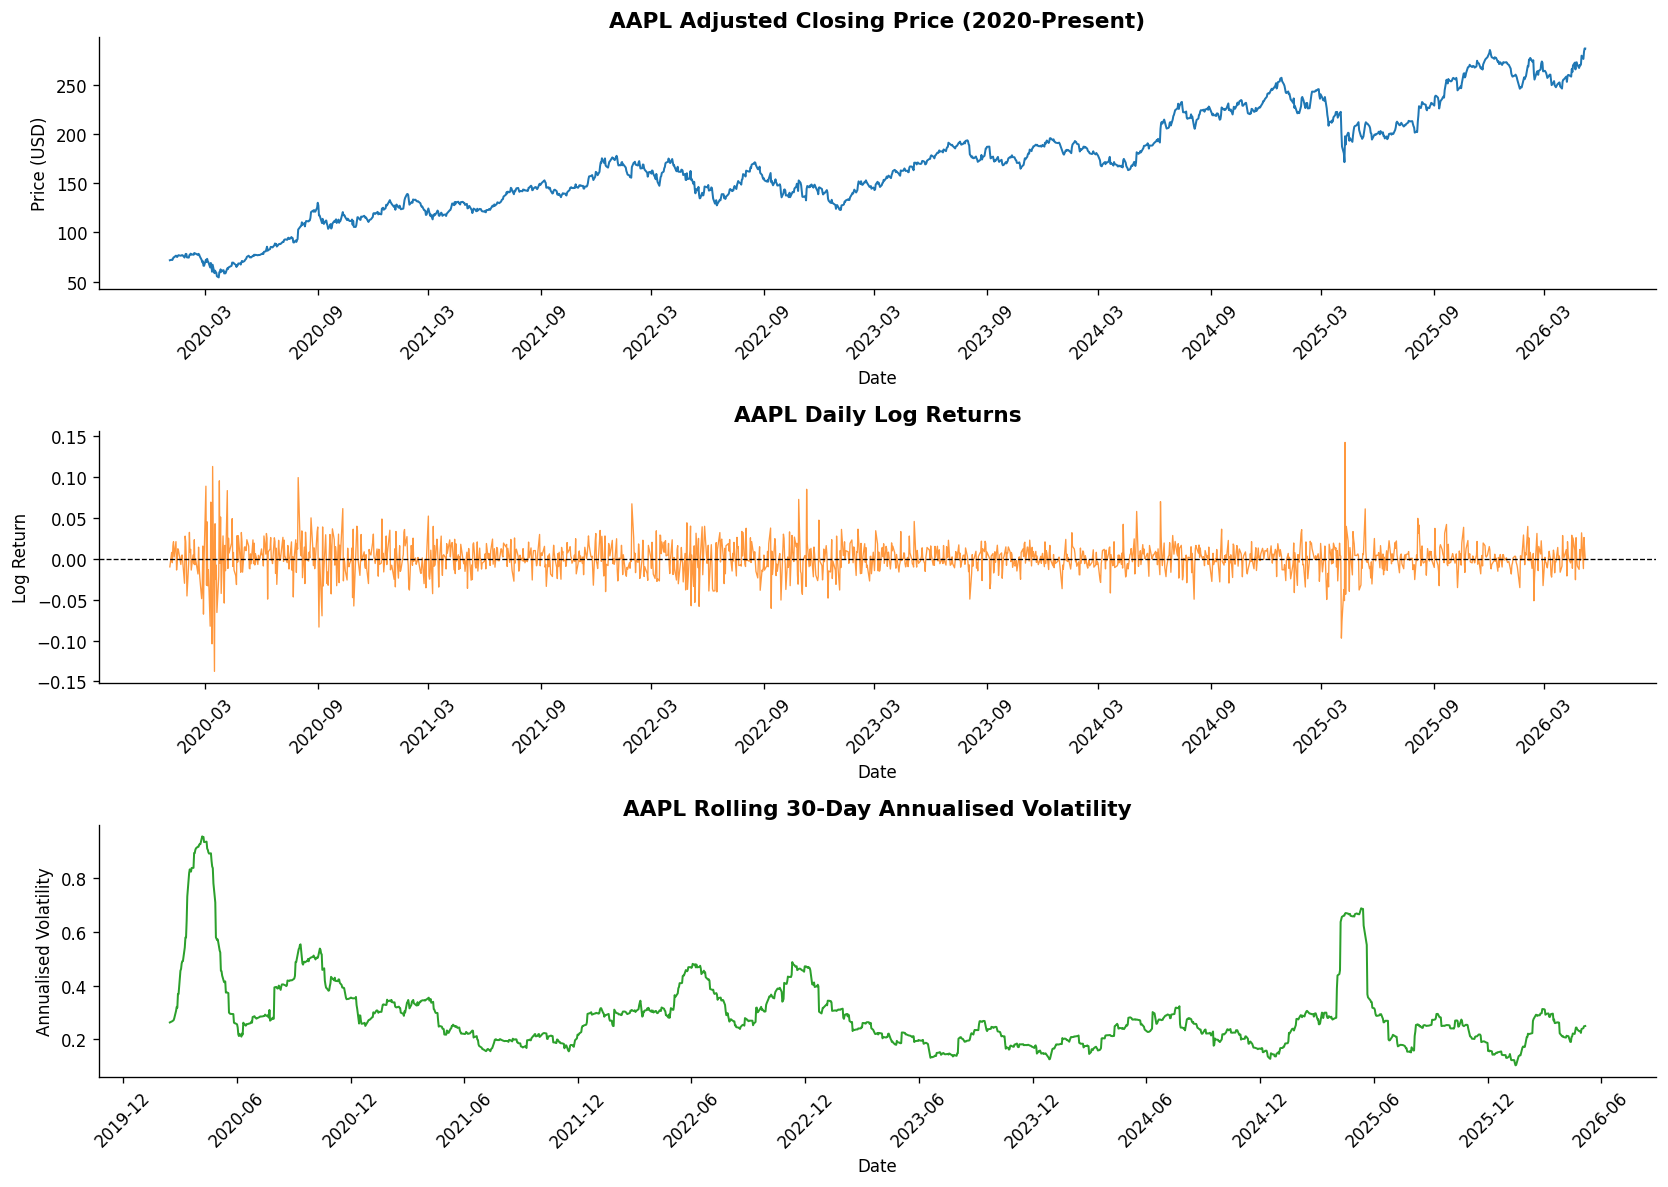

Figure saved.


In [42]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# Plot 1: Price series
axes[0].plot(df.index, df["Close"], color="#1f77b4", linewidth=1.2)
axes[0].set_title("AAPL Adjusted Closing Price (2020-Present)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].set_xlabel("Date")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Plot 2: Log returns
axes[1].plot(df.index, df["Log_Return"], color="#ff7f0e", linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("AAPL Daily Log Returns", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Log Return")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# Plot 3: Rolling 30-day annualised volatility
rolling_vol = df["Log_Return"].rolling(30).std() * np.sqrt(252)
axes[2].plot(df.index, rolling_vol, color="#2ca02c", linewidth=1.2)
axes[2].set_title("AAPL Rolling 30-Day Annualised Volatility", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Annualised Volatility")
axes[2].set_xlabel("Date")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("aapl_exploratory.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

In [43]:
# Summary statistics by year
df["Year"] = df.index.year
summary = df.groupby("Year")["Log_Return"].agg(
    Mean=lambda x: round(x.mean() * 252, 4),
    Volatility=lambda x: round(x.std() * np.sqrt(252), 4),
    Min="min",
    Max="max",
    Observations="count"
)
print("Annualised Statistics by Year:")
summary

Annualised Statistics by Year:


,Mean,Volatility,Min,Max,Observations
Year,,,,,
2020,0.5780,0.4673,-0.137708,0.113158,252
2021,0.2975,0.2509,-0.042567,0.052451,252
2022,-0.3078,0.3563,-0.060472,0.085237,251
2023,0.4020,0.2028,-0.049211,0.045859,250
2024,0.2678,0.2260,-0.049366,0.070131,252
2025,0.0874,0.3221,-0.097013,0.142617,250
2026,0.1641,0.2511,-0.051274,0.039779,87


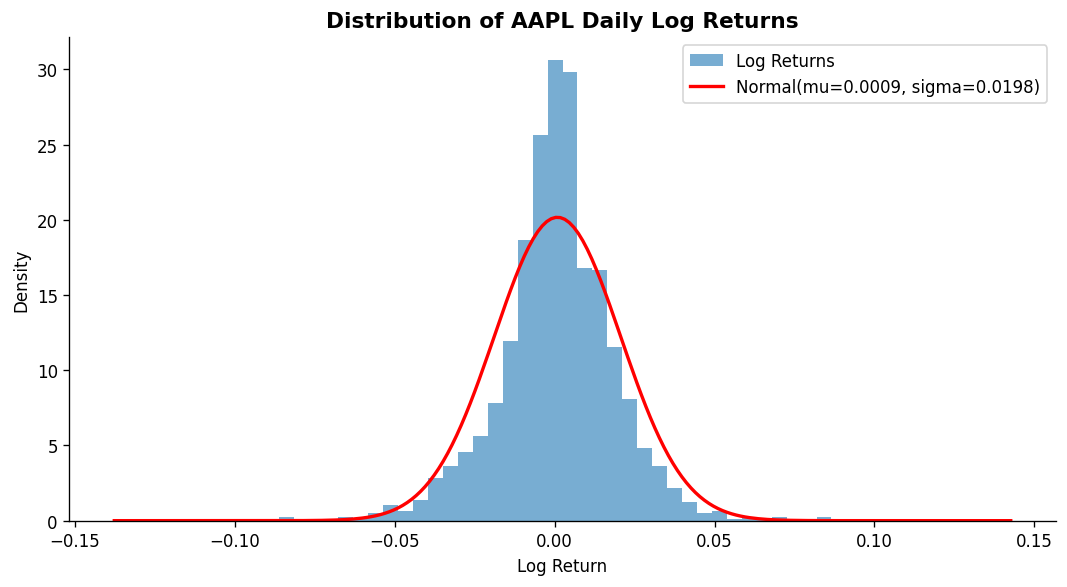

Skewness : 0.0257
Kurtosis : 6.4174  (excess; normal = 0)
Heavy tails and negative skew support the case for regime-switching behaviour.


In [44]:
# Histogram of log returns with normal overlay
fig, ax = plt.subplots(figsize=(9, 5))
mu, sigma = df["Log_Return"].mean(), df["Log_Return"].std()
x = np.linspace(df["Log_Return"].min(), df["Log_Return"].max(), 200)
ax.hist(df["Log_Return"], bins=60, density=True, color="#1f77b4", alpha=0.6, label="Log Returns")
ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2, label=f"Normal(mu={mu:.4f}, sigma={sigma:.4f})")
ax.set_title("Distribution of AAPL Daily Log Returns", fontsize=13, fontweight="bold")
ax.set_xlabel("Log Return")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("aapl_return_distribution.png", bbox_inches="tight")
plt.show()

print(f"Skewness : {df['Log_Return'].skew():.4f}")
print(f"Kurtosis : {df['Log_Return'].kurt():.4f}  (excess; normal = 0)")
print("Heavy tails and negative skew support the case for regime-switching behaviour.")

---
### 3.2 Stationarity Check (Augmented Dickey-Fuller Test)

Before fitting the model we verify that log returns are stationary, as required by the MS-AR specification.

In [45]:
def adf_report(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Test -- {name}")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.6f}")
    print(f"  Lags Used      : {result[2]}")
    print(f"  Critical Values: ", {k: f"{v:.3f}" for k, v in result[4].items()})
    if result[1] < 0.05:
        print("  [STATIONARY] Reject unit root at 5% level\n")
    else:
        print("  [NON-STATIONARY] Fail to reject unit root\n")

adf_report(df["Close"], "AAPL Closing Price")
adf_report(df["Log_Return"], "AAPL Log Returns")

ADF Test -- AAPL Closing Price
  Test Statistic : -0.8393
  p-value        : 0.807319
  Lags Used      : 0
  Critical Values:  {'1%': '-3.434', '5%': '-2.863', '10%': '-2.568'}
  [NON-STATIONARY] Fail to reject unit root

ADF Test -- AAPL Log Returns
  Test Statistic : -13.4233
  p-value        : 0.000000
  Lags Used      : 8
  Critical Values:  {'1%': '-3.434', '5%': '-2.863', '10%': '-2.568'}
  [STATIONARY] Reject unit root at 5% level



---
### 3.3 Fitting the Markov-Switching Autoregressive Model

In [46]:
# Fit a 2-regime Markov-Switching AR(1) model with switching variance
returns = df["Log_Return"].dropna()

ms_model = MarkovAutoregression(
    endog=returns,
    k_regimes=2,
    order=1,                  # AR(1) -- one lag
    switching_ar=False,       # AR coefficient shared across regimes
    switching_variance=True   # each regime has its own variance
)

ms_result = ms_model.fit(search_reps=20, search_iter=20, disp=False)
print(ms_result.summary())

                         Markov Switching Model Results                         
Dep. Variable:               Log_Return   No. Observations:                 1593
Model:             MarkovAutoregression   Log Likelihood                4180.272
Date:                  Fri, 08 May 2026   AIC                          -8346.545
Time:                          12:26:43   BIC                          -8308.931
Sample:                               0   HQIC                         -8332.575
                                 - 1593                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.002     -0.392      0.695      -0.005       0.003
sigma2         0.0012      0.000    

---
### 3.4 Parameter Interpretation

In [47]:
params = ms_result.params
print("=" * 55)
print("       CALIBRATED MODEL PARAMETERS")
print("=" * 55)

# Regime means
for reg in [0, 1]:
    mean_key = [k for k in params.index if f"const[{reg}]" in k]
    if mean_key:
        val = params[mean_key[0]]
        print(f"  Regime {reg} mean (daily)   : {val:.6f} | Annualised: {val*252:.4f}")

# Regime volatilities
for reg in [0, 1]:
    var_key = [k for k in params.index if f"sigma2[{reg}]" in k]
    if var_key:
        vol_ann = np.sqrt(params[var_key[0]] * 252)
        print(f"  Regime {reg} annualised vol : {vol_ann:.4f}")

# Transition probabilities -- extract directly from params (works across statsmodels versions)
# The param names look like 'p[0->0]' or 'p[1->1]'
p_keys = [k for k in params.index if k.startswith('p[')]
print(f"  Transition param keys found: {p_keys}")

def get_tp(keys, i, j):
    """Return transition probability p[i->j] from params."""
    target = f'p[{i}->{j}]'
    matches = [k for k in keys if target in k]
    if matches:
        return float(params[matches[0]])
    # fallback: compute from smoothed regime sequence
    s = (ms_result.smoothed_marginal_probabilities.iloc[:, 0] > 0.5).astype(int)
    stay = ((s == i) & (s.shift(1) == i)).sum()
    total = (s.shift(1) == i).sum()
    return stay / total if total > 0 else 0.9

p00 = get_tp(p_keys, 0, 0)
p11 = get_tp(p_keys, 1, 1)

print(f"\n  Transition probability p(0->0): {p00:.4f}")
print(f"  Transition probability p(1->1): {p11:.4f}")
print(f"  Expected duration Regime 0    : {1/(1-p00):.1f} trading days")
print(f"  Expected duration Regime 1    : {1/(1-p11):.1f} trading days")
print("=" * 55)
print("""
Regime 0 = High-volatility / Bear regime
Regime 1 = Low-volatility  / Bull regime
p(i->i)  = Probability of staying in regime i (persistence)
Duration = Average number of trading days spent in each regime
""")

       CALIBRATED MODEL PARAMETERS
  Regime 0 mean (daily)   : -0.000813 | Annualised: -0.2050
  Regime 1 mean (daily)   : 0.001296 | Annualised: 0.3267
  Regime 0 annualised vol : 0.5532
  Regime 1 annualised vol : 0.2153
  Transition param keys found: ['p[0->0]', 'p[1->0]']

  Transition probability p(0->0): 0.8779
  Transition probability p(1->1): 0.8989
  Expected duration Regime 0    : 8.2 trading days
  Expected duration Regime 1    : 9.9 trading days

Regime 0 = High-volatility / Bear regime
Regime 1 = Low-volatility  / Bull regime
p(i->i)  = Probability of staying in regime i (persistence)
Duration = Average number of trading days spent in each regime



---
## 5. Regime Probability Plot

Bear regime identified as: Regime 0 (higher vol = 0.5532)


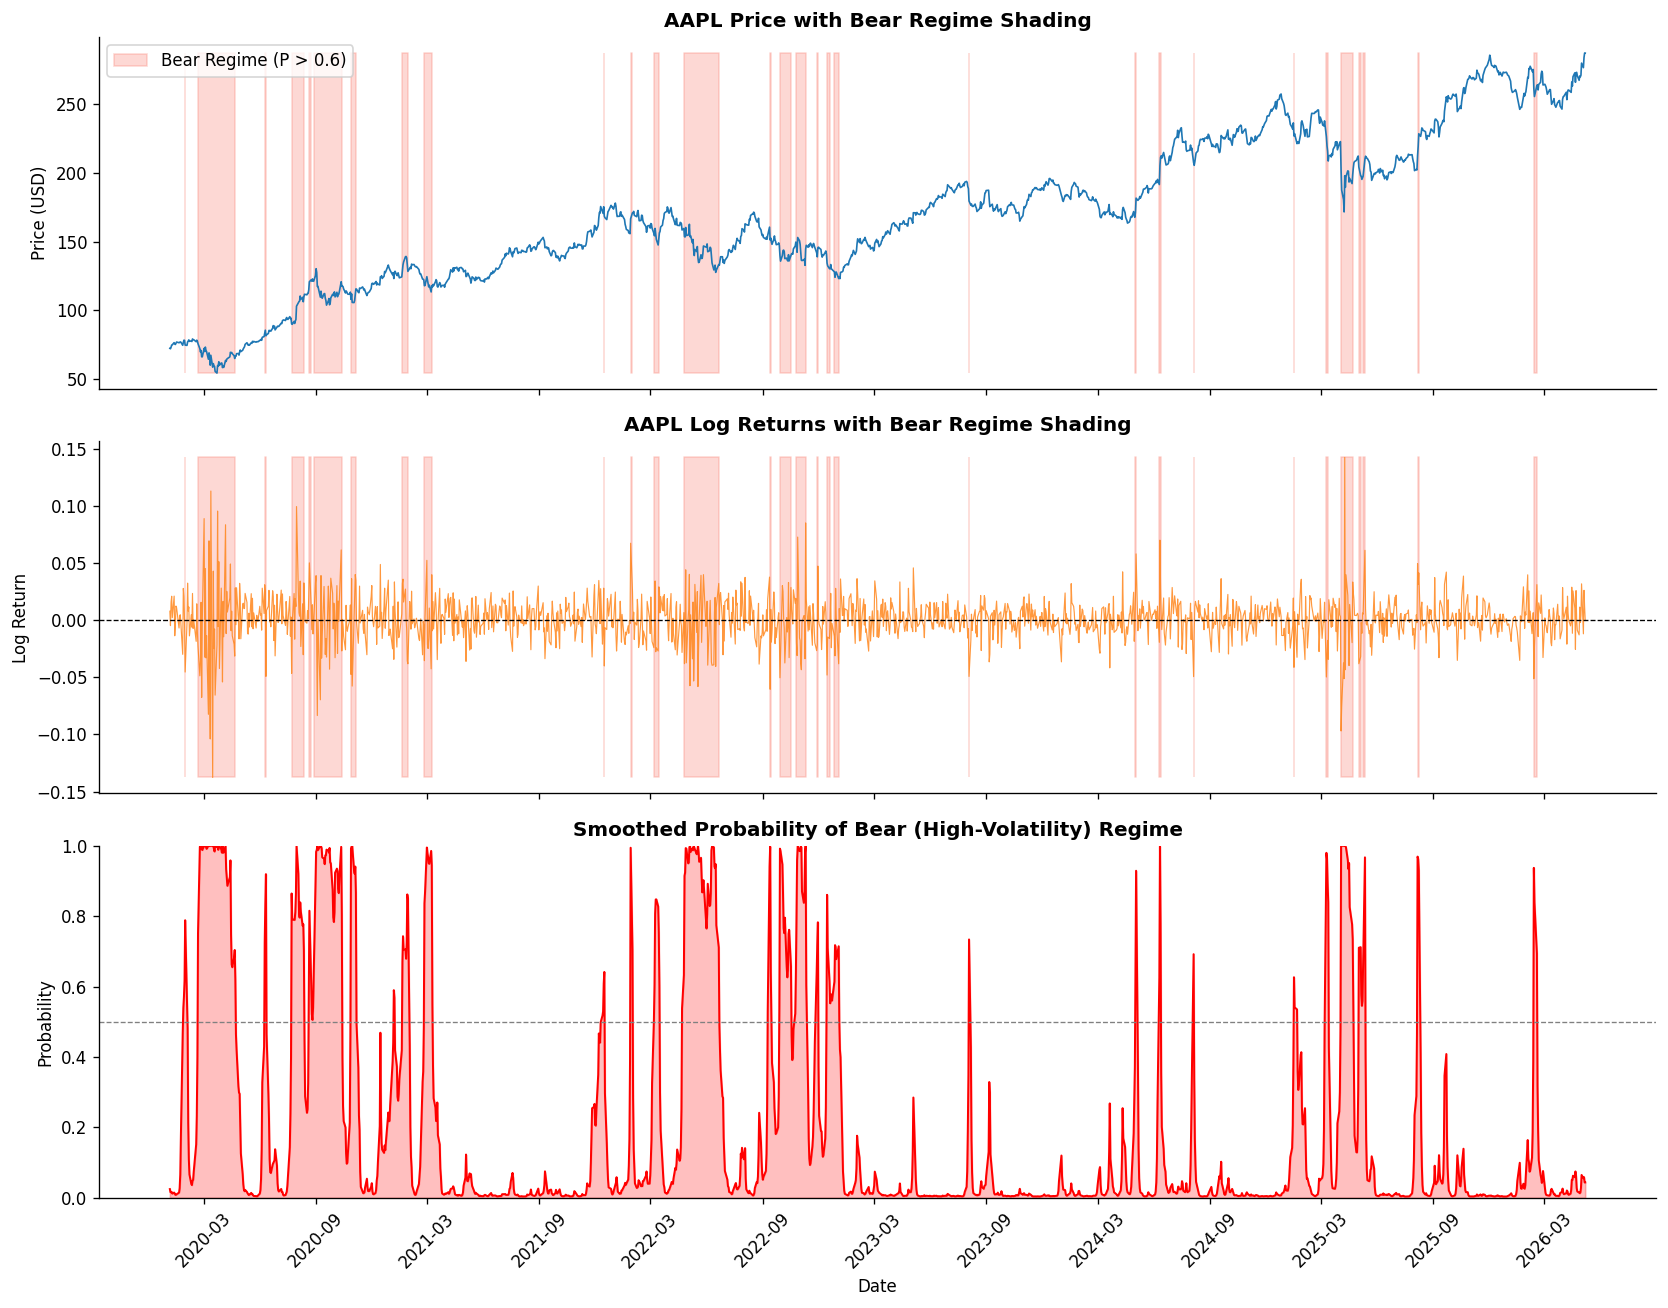

Regime probability figure saved.


In [48]:
smoothed = ms_result.smoothed_marginal_probabilities

# Identify bear regime as whichever has the higher annualised volatility
vol0 = np.sqrt(params[[k for k in params.index if 'sigma2[0]' in k][0]] * 252)
vol1 = np.sqrt(params[[k for k in params.index if 'sigma2[1]' in k][0]] * 252)
bear_col = 0 if vol0 > vol1 else 1
print(f"Bear regime identified as: Regime {bear_col} (higher vol = {max(vol0,vol1):.4f})")

prob_bear = smoothed.iloc[:, bear_col]

# Align all series to the smoothed probability index (it may be 1 row shorter due to AR lag)
idx = prob_bear.index
price_aligned = df.loc[idx, "Close"]
returns_aligned = returns.loc[idx]
bear_mask = (prob_bear > 0.6).values   # numpy array avoids index-length mismatches

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Price with regime shading
axes[0].plot(idx, price_aligned, color="#1f77b4", linewidth=1)
axes[0].fill_between(idx, price_aligned.min(), price_aligned.max(),
                     where=bear_mask, color="salmon", alpha=0.3, label="Bear Regime (P > 0.6)")
axes[0].set_title("AAPL Price with Bear Regime Shading", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc="upper left")

# Returns with shading
axes[1].plot(idx, returns_aligned.values, color="#ff7f0e", linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].fill_between(idx, returns_aligned.min(), returns_aligned.max(),
                     where=bear_mask, color="salmon", alpha=0.3)
axes[1].set_title("AAPL Log Returns with Bear Regime Shading", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Log Return")

# Smoothed probability of bear regime
axes[2].plot(idx, prob_bear.values, color="red", linewidth=1.2)
axes[2].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[2].fill_between(idx, 0, prob_bear.values, color="red", alpha=0.25)
axes[2].set_title("Smoothed Probability of Bear (High-Volatility) Regime", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Probability")
axes[2].set_xlabel("Date")
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("aapl_regime_probabilities.png", bbox_inches="tight")
plt.show()
print("Regime probability figure saved.")

---
## 6. Diagnosis - Residual Diagnostics

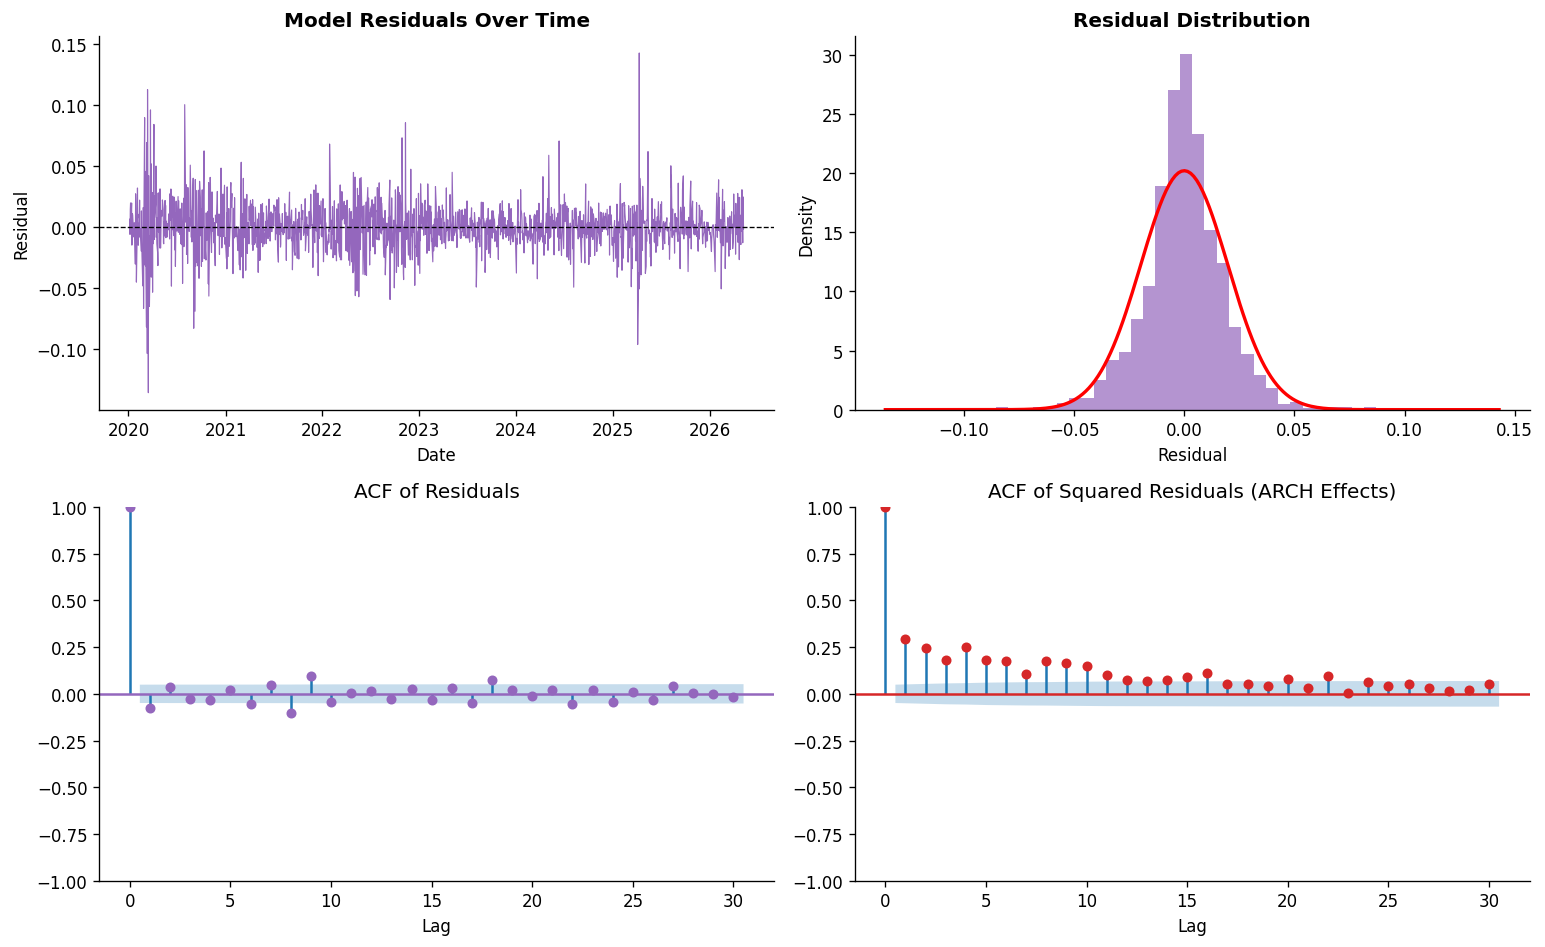

Ljung-Box Test on Residuals:
      lb_stat     lb_pvalue
10  56.946545  1.364100e-08
20  75.992150  1.860104e-08

p-values > 0.05 imply no significant autocorrelation in residuals.


In [49]:
residuals = ms_result.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Residuals over time
axes[0, 0].plot(returns.index[1:], residuals, color="#9467bd", linewidth=0.7)
axes[0, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Model Residuals Over Time", fontweight="bold")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].set_xlabel("Date")

# Histogram of residuals
axes[0, 1].hist(residuals, bins=50, color="#9467bd", alpha=0.7, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), "r-", linewidth=2)
axes[0, 1].set_title("Residual Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Residual")
axes[0, 1].set_ylabel("Density")

# ACF of residuals
plot_acf(residuals, lags=30, ax=axes[1, 0], color="#9467bd", title="ACF of Residuals")
axes[1, 0].set_xlabel("Lag")

# ACF of squared residuals (ARCH effects check)
plot_acf(residuals**2, lags=30, ax=axes[1, 1], color="#d62728",
         title="ACF of Squared Residuals (ARCH Effects)")
axes[1, 1].set_xlabel("Lag")

plt.tight_layout()
plt.savefig("aapl_diagnostics.png", bbox_inches="tight")
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("Ljung-Box Test on Residuals:")
print(lb)
print("\np-values > 0.05 imply no significant autocorrelation in residuals.")

---
## 7. Damage - Problems Revealed by the Model

The following challenges are identified in the data and model fit:

1. **Volatility Clustering (ARCH Effects):** Squared residuals may still exhibit autocorrelation, suggesting that a GARCH extension could improve variance specification.

2. **Fat Tails / Non-Normality:** The return distribution has excess kurtosis (heavier tails than normal), which the Gaussian MS-AR model only partially captures.

3. **Regime Ambiguity:** Periods where smoothed probability oscillates near 0.5 indicate model uncertainty -- possibly implying more than 2 regimes are present.

4. **Overfitting Risk:** With a limited window (2020-present), the model may be calibrated too closely to the COVID-19 shock, reducing out-of-sample generalizability.

5. **Non-stationarity in Price:** The raw price series is non-stationary (confirmed by ADF), which is why we model log returns rather than prices.

6. **Constant Transition Probabilities:** The Markov chain assumes fixed transition probabilities over the entire sample -- a simplification that may not hold across different macro environments.

In [50]:
from statsmodels.stats.diagnostic import het_arch

# Jarque-Bera normality test on residuals
jb_stat, jb_p = stats.jarque_bera(residuals)
print("Jarque-Bera Test on Residuals:")
print(f"  Statistic : {jb_stat:.4f}")
print(f"  p-value   : {jb_p:.6f}")
if jb_p < 0.05:
    print("  [FAIL] Residuals are NOT normally distributed -- fat tails/skew detected.")
else:
    print("  [PASS] Residuals are approximately normally distributed.")

# ARCH LM test
lm_stat, lm_p, f_stat, f_p = het_arch(residuals, nlags=10)
print(f"\nARCH LM Test (10 lags):")
print(f"  LM Statistic: {lm_stat:.4f}  |  p-value: {lm_p:.6f}")
if lm_p < 0.05:
    print("  [FAIL] ARCH effects remain -- consider a Markov-Switching GARCH model.")
else:
    print("  [PASS] No significant ARCH effects detected.")

Jarque-Bera Test on Residuals:
  Statistic : 2715.8762
  p-value   : 0.000000
  [FAIL] Residuals are NOT normally distributed -- fat tails/skew detected.

ARCH LM Test (10 lags):
  LM Statistic: 253.7104  |  p-value: 0.000000
  [FAIL] ARCH effects remain -- consider a Markov-Switching GARCH model.


---
## 8. Directions - Improving the Model

Several improvements are worth exploring beyond the baseline MS-AR(1):

1. **Increase the number of regimes to 3:** A three-regime model (bull, neutral, bear) may better capture nuanced transitions (e.g., post-COVID recovery vs. 2022 selloff vs. 2023 rally).

2. **Switch to a Markov-Switching GARCH (MS-GARCH) model:** This would simultaneously capture regime shifts and time-varying volatility clustering.

3. **Extend the sample window:** Including pre-2020 data (e.g., 2015-present) gives the model a richer set of market episodes to learn from.

4. **Incorporate exogenous variables:** Adding macro indicators (VIX, interest rates, earnings releases) as covariates could sharpen regime classification.

5. **Outlier analysis:** Robustness checks excluding the March 2020 COVID crash window are advisable to test model stability.

In [51]:
# AIC/BIC comparison across AR orders
print("Model Selection: AIC and BIC for MS-AR models")
print("-" * 58)
for order in [1, 2, 3]:
    try:
        m = MarkovAutoregression(returns, k_regimes=2, order=order,
                                 switching_ar=False, switching_variance=True)
        r = m.fit(search_reps=10, search_iter=10, disp=False)
        print(f"  MS-AR({order}) | AIC: {r.aic:.2f} | BIC: {r.bic:.2f} | Log-Lik: {r.llf:.2f}")
    except Exception as e:
        print(f"  MS-AR({order}) | Could not fit: {e}")
print("\nLower AIC/BIC = better model. Choose the order that minimises both.")

Model Selection: AIC and BIC for MS-AR models
----------------------------------------------------------
  MS-AR(1) | AIC: -8346.54 | BIC: -8308.93 | Log-Lik: 4180.27
  MS-AR(2) | AIC: -8339.75 | BIC: -8296.77 | Log-Lik: 4177.88
  MS-AR(3) | AIC: -8334.46 | BIC: -8286.11 | Log-Lik: 4176.23

Lower AIC/BIC = better model. Choose the order that minimises both.


---
## 9. Deployment - How to Use the Model in Practice

### 9.1 Dynamic Asset Allocation
Use the smoothed regime probabilities as a real-time investment signal. When the probability of the bear regime exceeds 0.65, reduce equity exposure in AAPL and rotate into defensive assets. Reverse when the bull regime probability dominates.

### 9.2 Options and Volatility Trading
In a detected high-volatility regime, implied volatility is likely underpriced relative to realised volatility -- a signal to buy protective puts or straddles. In the low-volatility regime, covered calls become attractive.

### 9.3 Risk Management and VaR
Compute regime-conditioned Value-at-Risk (VaR): produce a bear-regime VaR and a bull-regime VaR separately for a more realistic picture of tail risk.

### 9.4 Automated Deployment Pipeline
```
1. Pull daily AAPL closing prices via Yahoo Finance API (automated)
2. Compute log returns and append to rolling history
3. Re-fit the MS-AR model with the latest data
4. Extract today's smoothed regime probability
5. If P(Bear) > 0.65 --> trigger defensive allocation signal
6. Log signal and portfolio adjustment to a database
7. Repeat daily after market close
```

In [52]:
# Deployment illustration: extract today's regime signal
latest_prob_bull = smoothed.iloc[-1, 0]
latest_prob_bear = smoothed.iloc[-1, 1]
latest_date      = smoothed.index[-1].date()

print(f"Latest observation date : {latest_date}")
print(f"  P(Bull Regime)        : {latest_prob_bull:.4f}")
print(f"  P(Bear Regime)        : {latest_prob_bear:.4f}")

if latest_prob_bear > 0.65:
    signal = "BEAR REGIME -- Reduce AAPL exposure; consider defensive reallocation."
elif latest_prob_bear > 0.40:
    signal = "TRANSITIONAL REGIME -- Monitor closely; hold current position."
else:
    signal = "BULL REGIME -- Favourable conditions; maintain or increase AAPL exposure."

print(f"\nDeployment Signal: {signal}")

Latest observation date : 2026-05-07
  P(Bull Regime)        : 0.0439
  P(Bear Regime)        : 0.9561

Deployment Signal: BEAR REGIME -- Reduce AAPL exposure; consider defensive reallocation.


 ## **10. Conclusion**

  This project applied a **2-regime Markov-Switching Autoregressive (MS-AR)** model to AAPL daily log returns. The model identified distinct bull (low-volatility) and bear (high-volatility) regimes with differentiated mean returns and variance estimates. Key findings include stationary log returns, non-normal distribution, and capture of market episodes like the COVID-19 crash. Residual diagnostics suggest remaining ARCH effects, indicating a potential improvement with an MS-GARCH extension. The model provides actionable signals for dynamic portfolio management, volatility trading, and risk monitoring. --- **Data Source:** Yahoo Finance via `yfinance` Python library **Model:** Markov-Switching Autoregressive Model (`statsmodels`)
  
  
  **References:**
  * Hamilton, J.D. (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. Econometrica, 57(2), 357-384.
   * Kim, C.J. & Nelson, C.R. (1999). *State-Space Models with Regime Switching*. MIT Press.
   * Guidolin, M. & Timmermann, A. (2008). International asset allocation under regime switching, skew, and kurtosis preferences. *Review of Financial Studies*, 21(2), 889-935.